In [1]:
!unzip glove.v1i.yolov8.zip

Archive:  glove.v1i.yolov8.zip
 extracting: README.dataset.txt      
 extracting: README.roboflow.txt     
 extracting: data.yaml               
   creating: test/
   creating: test/images/
 extracting: test/images/20220225_103259_jpg.rf.365765f491604a7376af4e8cf00f6d8b.jpg  
 extracting: test/images/IMG20220224160807-1-_jpg.rf.0e6b5ef655e3ff4afbbd67f049b6a63b.jpg  
 extracting: test/images/IMG20220224160840_jpg.rf.354959c9070c5b86c661a533feae83a6.jpg  
 extracting: test/images/IMG20220224160928_jpg.rf.204ebb54112b265c2cecf3ff209ae236.jpg  
 extracting: test/images/IMG20220224162653_jpg.rf.d74c1b8b73da34dd9456cf46bc29a6c6.jpg  
 extracting: test/images/IMG20220224164705_jpg.rf.1f6ff0527f786e18ad04ffb61c3cb0f9.jpg  
 extracting: test/images/IMG20220224170028_jpg.rf.4957f65b4089c279ace77bbb3d34c691.jpg  
 extracting: test/images/IMG20220224172210_jpg.rf.893fde2d2ef4e33ab0acbab260c8d905.jpg  
 extracting: test/images/IMG20220224231707_jpg.rf.f60de50d501f2d9d61e34961d88da3a3.jpg  
 extract

In [2]:
!ls


data.yaml	      README.dataset.txt   sample_data	train
glove.v1i.yolov8.zip  README.roboflow.txt  test		valid


In [3]:
!ls train/labels | wc -l


1462


In [4]:
!ls valid/labels | wc -l


138


In [5]:
!cat data.yaml


train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['glove', 'no_glove']

roboflow:
  workspace: glove-uylxg
  project: glove-q7czq
  version: 1
  license: MIT
  url: https://universe.roboflow.com/glove-uylxg/glove-q7czq/dataset/1

In [6]:
%%writefile data.yaml
train: train/images
val: valid/images
test: test/images

nc: 2
names: ['glove', 'no_glove']


Overwriting data.yaml


In [7]:
!ls train/labels | wc -l
!ls valid/labels | wc -l


1462
138


In [8]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.3 MB/s eta 0:00:00


In [10]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="data.yaml",
    epochs=120,
    imgsz=640,
    batch=16,
    patience=25
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=25, perspective=0.0, plots=True, po

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783f3568de80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [14]:
import os
import cv2
import json
from ultralytics import YOLO

def run_detection(input_folder, output_folder, confidence):
    model = YOLO("/content/runs/detect/train2/weights/best.pt")

    os.makedirs(output_folder, exist_ok=True)
    os.makedirs("logs", exist_ok=True)

    for image_name in os.listdir(input_folder):
        if not image_name.endswith(".jpg") and not image_name.endswith(".png") and not image_name.endswith(".jpeg"):
            continue

        image_path = os.path.join(input_folder, image_name)
        image = cv2.imread(image_path)

        results = model(image, conf=confidence)

        detections_list = []

        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = float(box.conf[0])
                cls_id = int(box.cls[0])
                label = model.names[cls_id]

                detections_list.append({
                    "label": label,
                    "confidence": round(conf, 3),
                    "bbox": [int(x1), int(y1), int(x2), int(y2)]
                })

                # Draw box
                cv2.rectangle(image,
                              (int(x1), int(y1)),
                              (int(x2), int(y2)),
                              (0, 255, 0), 2)

                cv2.putText(image,
                            f"{label} {conf:.2f}",
                            (int(x1), int(y1) - 10),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.5,
                            (0, 255, 0),
                            2)

        # Save annotated image
        cv2.imwrite(os.path.join(output_folder, image_name), image)

        # Save JSON log
        log_data = {
            "filename": image_name,
            "detections": detections_list
        }

        with open(f"logs/{image_name}.json", "w") as f:
            json.dump(log_data, f, indent=4)


if __name__ == "__main__":
    # Directly set input/output folders and confidence
    input_folder = "test/images"
    output_folder = "output"
    confidence = 0.5

    run_detection(input_folder, output_folder, confidence)


0: 640x640 1 glove, 16.2ms
Speed: 2.2ms preprocess, 16.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 glove, 15.9ms
Speed: 2.3ms preprocess, 15.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 glove, 15.9ms
Speed: 2.1ms preprocess, 15.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 glove, 15.8ms
Speed: 2.0ms preprocess, 15.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 no_glove, 15.9ms
Speed: 2.1ms preprocess, 15.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 glove, 15.9ms
Speed: 2.5ms preprocess, 15.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 glove, 15.9ms
Speed: 2.1ms preprocess, 15.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 no_glove, 15.9ms
Speed: 2.2ms preprocess, 15.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640,

In [19]:
import os

output_files = os.listdir('output')
print(f"Files in 'output' folder: {output_files}")

Files in 'output' folder: ['wq077_jpg.rf.adbbbeab8b3a8f91395bcbc899d6598c.jpg', 'wq117_jpg.rf.c6880e8e43d4c630cea27c54f5358faf.jpg', 'wq015_jpg.rf.e814b73f52eeda2d6c2faa852a37e0a5.jpg', 'wq076_jpg.rf.ab07f41b90f10ae43497c4419b67ab80.jpg', 'IMG_3831_JPG.rf.7e44bac09a4db563a7f9bc33bb830a79.jpg', 'wq085_jpg.rf.bb93949dd2667804dce050fa969b2fda.jpg', 'w072_jpg.rf.309be5ce9d0af94ef9cb6257c058722d.jpg', 'IMG20220226133129_jpg.rf.56ff65ce8fa20e06542320e6b4587bd5.jpg', 'wq102_jpg.rf.08f33741326c3a5433f59fad17ad64e2.jpg', 'wq113_jpg.rf.3035f126a81f31acd2496713cd1257fc.jpg', 'IMG20220226133043_jpg.rf.b788463fa1ef8a69b60d9ffe4b1e3535.jpg', 'w047_jpg.rf.7e67e79ab2c2b842f046eddff09f566a.jpg', 'S__34734224_jpg.rf.2c07dff6e2aeac765ba0fbc2e95c4cfb.jpg', 'IMG20220226234924_jpg.rf.0a86f1273ada688a4d76cde68c8f0daf.jpg', 'wq020_jpg.rf.31ea718331469c5e039c3ab2dd8fc94a.jpg', 'IMG20220224170028_jpg.rf.4957f65b4089c279ace77bbb3d34c691.jpg', 'w113_jpg.rf.31af384fc84917e75a08b0669c98ba01.jpg', 'IMG_3900_JPG.rf.b

Here are some of the detected images from the 'output' folder:

Displaying wq077_jpg.rf.adbbbeab8b3a8f91395bcbc899d6598c.jpg:


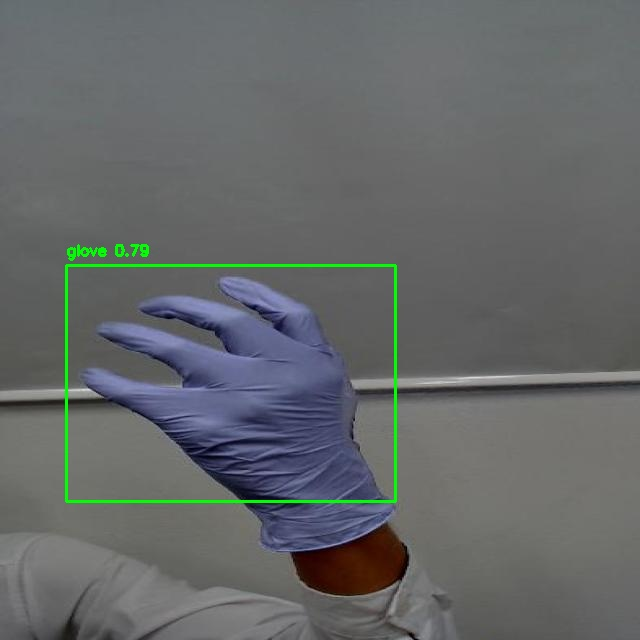

Displaying wq117_jpg.rf.c6880e8e43d4c630cea27c54f5358faf.jpg:


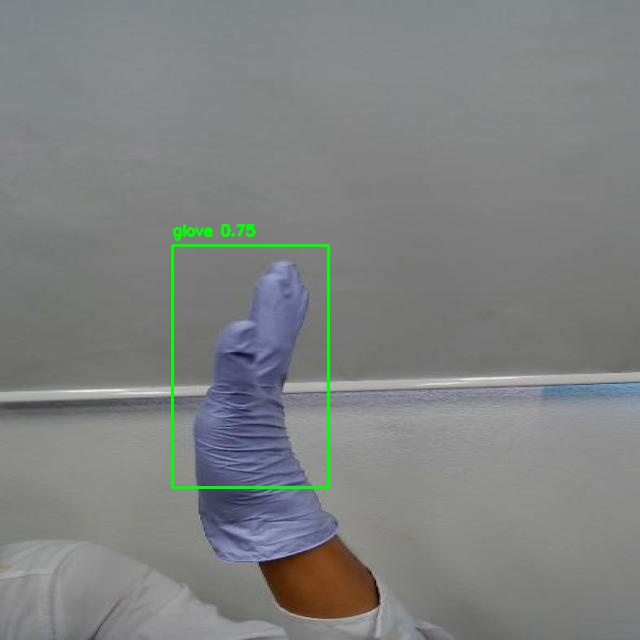

Displaying wq015_jpg.rf.e814b73f52eeda2d6c2faa852a37e0a5.jpg:


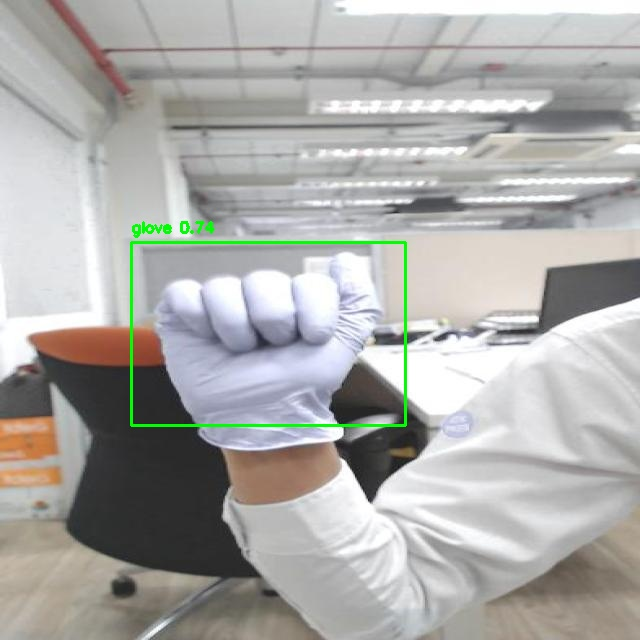

Displaying wq076_jpg.rf.ab07f41b90f10ae43497c4419b67ab80.jpg:


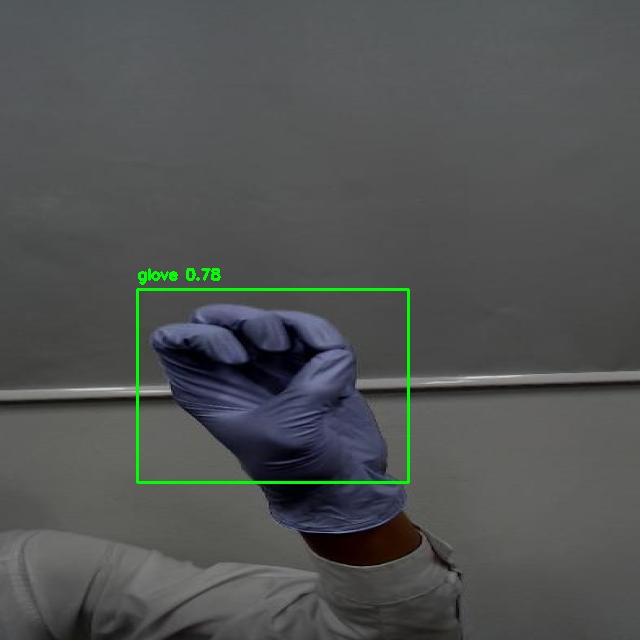

Displaying IMG_3831_JPG.rf.7e44bac09a4db563a7f9bc33bb830a79.jpg:


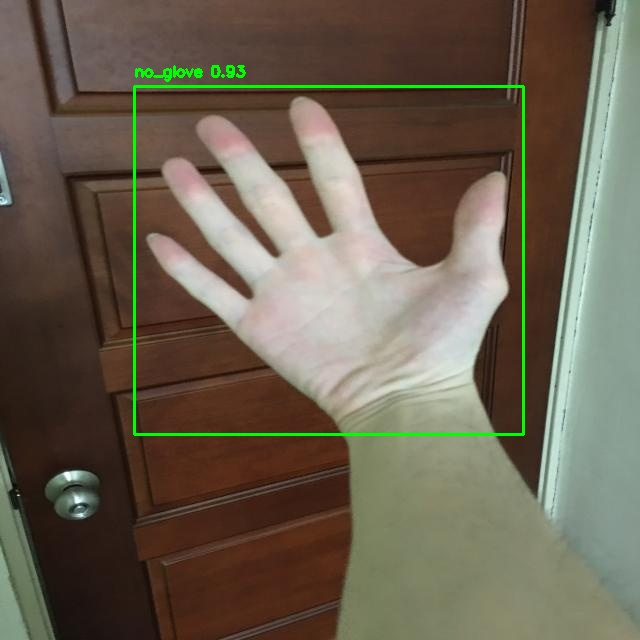

Displaying wq085_jpg.rf.bb93949dd2667804dce050fa969b2fda.jpg:


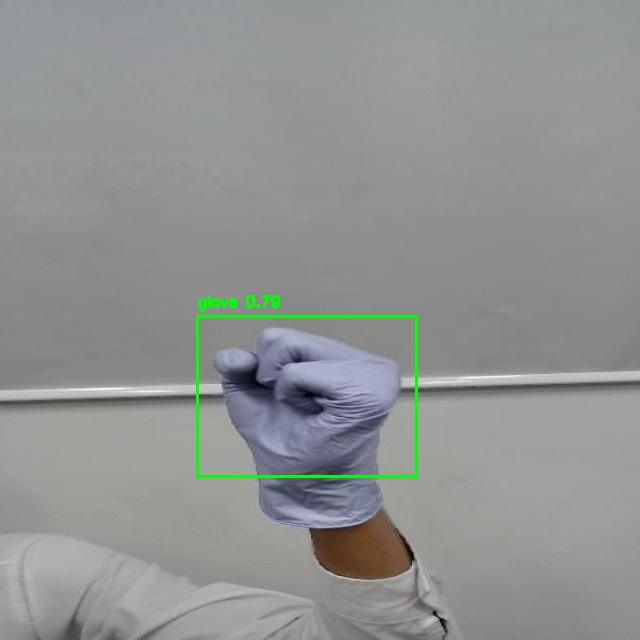

Displaying w072_jpg.rf.309be5ce9d0af94ef9cb6257c058722d.jpg:


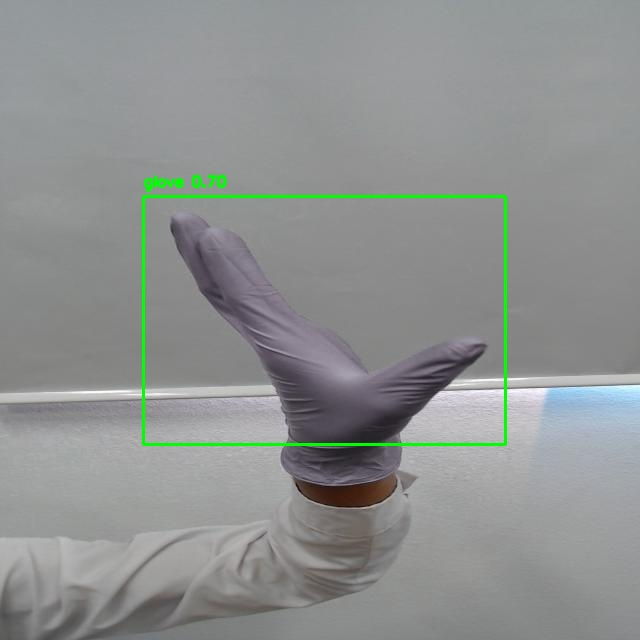

In [28]:
from IPython.display import Image, display

image_files = [f for f in os.listdir('output') if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Display up to 5 images
for i, image_file in enumerate(image_files[:7]):
    print(f"Displaying {image_file}:")
    display(Image(os.path.join('output', image_file)))

In [23]:
!python detection_script.py --input test_images --confidence 0.4


python3: can't open file '/content/detection_script.py': [Errno 2] No such file or directory


In [32]:
import os
import cv2
import json
from ultralytics import YOLO

def run_detection(input_folder, output_folder="output", confidence=0.5, model_path="best.pt"):
    model = YOLO(model_path)

    os.makedirs(output_folder, exist_ok=True)
    os.makedirs("logs", exist_ok=True)

    for image_name in os.listdir(input_folder):
        if not image_name.lower().endswith(('.jpg', '.png', '.jpeg')):
            continue

        image_path = os.path.join(input_folder, image_name)
        image = cv2.imread(image_path)

        if image is None:
            print(f"Skipping unreadable image: {image_name}")
            continue

        results = model(image, conf=confidence)

        detections = []

        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = float(box.conf[0])
                cls_id = int(box.cls[0])
                label = model.names[cls_id]

                # EXACT FORMAT
                detections.append({
                    "label": label,
                    "confidence": round(conf, 2),
                    "bbox": [
                        int(x1),
                        int(y1),
                        int(x2),
                        int(y2)
                    ]
                })

                # Draw bounding box
                cv2.rectangle(image,
                              (int(x1), int(y1)),
                              (int(x2), int(y2)),
                              (0, 255, 0), 2)

                cv2.putText(image,
                            f"{label} {conf:.2f}",
                            (int(x1), int(y1) - 10),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.5,
                            (0, 255, 0),
                            2)

        # Save annotated image
        cv2.imwrite(os.path.join(output_folder, image_name), image)

        # JSON EXACT STRUCTURE
        json_data = {
            "filename": image_name,
            "detections": detections
        }

        with open(f"logs/{image_name}.json", "w") as f:
            json.dump(json_data, f, indent=4)

        print(f"Processed {image_name}")

    print("All images processed successfully.")


if __name__ == "__main__":
    # Directly set input/output folders and confidence
    input_folder = "test/images"
    output_folder = "output"
    confidence = 0.5
    model_path = "/content/runs/detect/train2/weights/best.pt"

    run_detection(input_folder, output_folder=output_folder, confidence=confidence, model_path=model_path)


0: 640x640 1 glove, 35.7ms
Speed: 3.9ms preprocess, 35.7ms inference, 5.7ms postprocess per image at shape (1, 3, 640, 640)
Processed wq077_jpg.rf.adbbbeab8b3a8f91395bcbc899d6598c.jpg

0: 640x640 1 glove, 33.2ms
Speed: 5.5ms preprocess, 33.2ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 640)
Processed wq117_jpg.rf.c6880e8e43d4c630cea27c54f5358faf.jpg

0: 640x640 1 glove, 30.5ms
Speed: 3.8ms preprocess, 30.5ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Processed wq015_jpg.rf.e814b73f52eeda2d6c2faa852a37e0a5.jpg

0: 640x640 1 glove, 34.7ms
Speed: 4.5ms preprocess, 34.7ms inference, 5.6ms postprocess per image at shape (1, 3, 640, 640)
Processed wq076_jpg.rf.ab07f41b90f10ae43497c4419b67ab80.jpg

0: 640x640 1 no_glove, 29.5ms
Speed: 3.5ms preprocess, 29.5ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 640)
Processed IMG_3831_JPG.rf.7e44bac09a4db563a7f9bc33bb830a79.jpg

0: 640x640 1 glove, 37.5ms
Speed: 7.2ms preprocess, 37.5ms inference